# DiFuMo Soft Atlas GAT — Interactive Walkthrough

**Track 1 of the NeuroVLM GNN experiment.**

Nodes = 512 DiFuMo components · Edges = functional connectivity · Node features = per-paper activation coefficients · Objective = InfoNCE against SPECTER text embeddings.

| Phase | What happens |
|---|---|
| **1** | Build the brain graph (atlas → coefficients → FC matrix → edge tensors) |
| **2** | Assemble the PyG dataset and inspect a sample |
| **3** | Instantiate and verify the GAT model |
| **4** | Train with AdamW + cosine LR schedule |
| **5** | Evaluate recall@k and inspect attention weights |

## Setup

Install deps if needed, then add the repo `src/` to the path.

In [1]:
# ── Install PyTorch Geometric ─────────────────────────────────────────────────
# torch is already required; install torch_geometric first.
# torch_scatter / torch_sparse are OPTIONAL — GATConv works without them.
#
# Step 1 (required):
#   pip install torch_geometric
#
# Step 2 (optional, only if you hit a scatter/sparse error):
#   Find your torch version first:  python -c "import torch; print(torch.__version__)"
#   Then: pip install torch_scatter torch_sparse -f https://data.pyg.org/whl/torch-<VERSION>+cpu.html
#   e.g. for torch 2.10.0:
#   pip install torch_scatter torch_sparse -f https://data.pyg.org/whl/torch-2.10.0+cpu.html
#
# NOTE: torch must be installed *before* torch_scatter or the build will fail
#       with "ModuleNotFoundError: No module named 'torch'".

# !pip install torch_geometric

In [2]:
import sys
from pathlib import Path

# Add the repo src/ directory so neurovlm is importable without pip install -e .
repo_root = Path("..").resolve()
src_dir = repo_root / "src"
if str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))

print("Repo root:", repo_root)
print("src dir  :", src_dir)

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

print(f"torch {torch.__version__}")
print(f"device: {torch.device('mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu')}")

Repo root: /Users/borng/code/lab_work/neurovlm
src dir  : /Users/borng/code/lab_work/neurovlm/src
torch 2.10.0
device: mps


---
## Phase 1 — Build the Brain Graph

### 1a. Load raw brain flatmaps

Each paper in the NeuroVLM dataset has a 28,542-dim flatmap (brain activations masked to gray matter).  
We load all of them in one go — this is the raw material for computing DiFuMo coefficients.

In [3]:
from neurovlm.data import load_dataset

images_data = load_dataset("pubmed_images")

# load_dataset returns (images_tensor, pmids) or just the tensor
if isinstance(images_data, (tuple, list)):
    brain_flat_tensor, pmids_raw = images_data[0], images_data[1]
else:
    brain_flat_tensor = images_data
    pmids_raw = None

brain_flat = brain_flat_tensor.numpy().astype(np.float32)
pmids = pmids_raw.tolist() if pmids_raw is not None else list(range(len(brain_flat)))

print(f"Brain flatmaps : {brain_flat.shape}  (n_papers × n_masked_voxels)")
print(f"dtype          : {brain_flat.dtype}")
print(f"value range    : [{brain_flat.min():.3f}, {brain_flat.max():.3f}]")
print(f"n_pmids        : {len(pmids)}")

/Users/borng/miniforge3/envs/gnn/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Brain flatmaps : (30784, 28542)  (n_papers × n_masked_voxels)
dtype          : float32
value range    : [0.000, 1.000]
n_pmids        : 30784


### 1b. Load the DiFuMo component matrix P

`load_difumo_components()` fetches the 512-component DiFuMo atlas via nilearn (cached to `~/.nilearn/`) and applies the NeuroVLM brain mask so the voxel ordering aligns with the 28,542-dim flatmaps above.

Result: **P** with shape `(512, 28542)` — each row is a soft parcel map.

[fetch_atlas_difumo] Dataset found in /Users/borng/nilearn_data/difumo_atlases

/Users/borng/code/lab_work/neurovlm/src/neurovlm/gnn/atlas.py:56: UserWarning: imgs are being resampled to the mask_img resolution. This process is memory intensive. You might want to provide a target_affine that is equal to the affine of the imgs or resample the mask beforehand to save memory and computation time.
  P = masker.transform(atlas.maps)  # (dimension, n_voxels)


P shape  : (512, 28542)  (n_components × n_masked_voxels)
P dtype  : float32
P range  : [-0.0000, 0.0036]


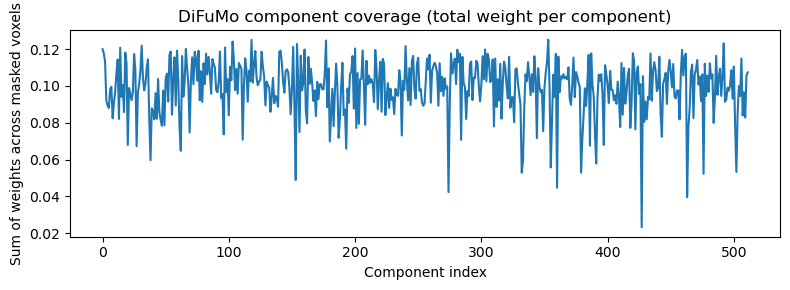

In [4]:
from neurovlm.gnn.atlas import load_difumo_components, DIFUMO_DIM

P = load_difumo_components(dimension=DIFUMO_DIM, resolution_mm=2)

print(f"P shape  : {P.shape}  (n_components × n_masked_voxels)")
print(f"P dtype  : {P.dtype}")
print(f"P range  : [{P.min():.4f}, {P.max():.4f}]")

# Quick visualisation: how much of each component overlaps with the mask
component_sums = P.sum(axis=1)
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(component_sums)
ax.set_xlabel("Component index")
ax.set_ylabel("Sum of weights across masked voxels")
ax.set_title("DiFuMo component coverage (total weight per component)")
plt.tight_layout()
plt.show()

### 1c. Compute per-paper DiFuMo coefficient vectors

Project each brain flatmap `y` onto the component matrix: `s = P @ y`.  
This gives one **512-dim coefficient vector per paper** — these become node features for the GAT.

`normalize=True` z-scores each component across papers. This is critical for training stability.

DiFuMo coefficients shape : (30784, 512)  (n_papers × n_components)
Mean (should be ~0)       : 0.0000
Std  (should be ~1)       : 1.0000


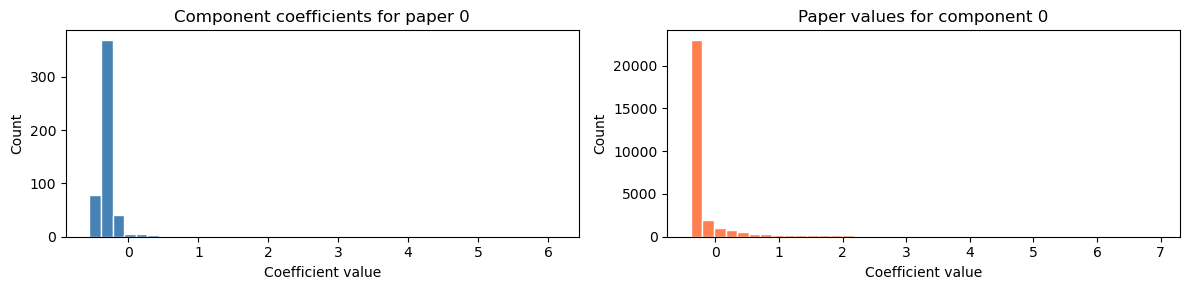

In [5]:
from neurovlm.gnn.atlas import compute_difumo_coefficients

difumo_coeffs = compute_difumo_coefficients(brain_flat, P, normalize=True)

print(f"DiFuMo coefficients shape : {difumo_coeffs.shape}  (n_papers × n_components)")
print(f"Mean (should be ~0)       : {difumo_coeffs.mean():.4f}")
print(f"Std  (should be ~1)       : {difumo_coeffs.std():.4f}")

# Visualise coefficient distribution for a random paper and a random component
fig, axes = plt.subplots(1, 2, figsize=(12, 3))

# Distribution across components for one paper
axes[0].hist(difumo_coeffs[0], bins=40, color="steelblue", edgecolor="white")
axes[0].set_title("Component coefficients for paper 0")
axes[0].set_xlabel("Coefficient value")
axes[0].set_ylabel("Count")

# Distribution across papers for one component
axes[1].hist(difumo_coeffs[:, 0], bins=40, color="coral", edgecolor="white")
axes[1].set_title("Paper values for component 0")
axes[1].set_xlabel("Coefficient value")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

### 1d. Functional connectivity matrix

Two options — pick one:

- **Option A (recommended):** load a precomputed HCP group-average FC matrix.  
  Download the parcellated FC in DiFuMo space from [humanconnectome.org](https://www.humanconnectome.org/) and set `FC_PATH` below.

- **Option B (no download needed):** compute a correlation matrix from the DiFuMo coefficients of the training papers. This is a *co-activation proxy* for true resting-state FC and works as a first baseline.

Computing FC matrix from DiFuMo co-activation patterns …
FC matrix shape : (512, 512)
FC range        : [-0.0000, 0.0000]


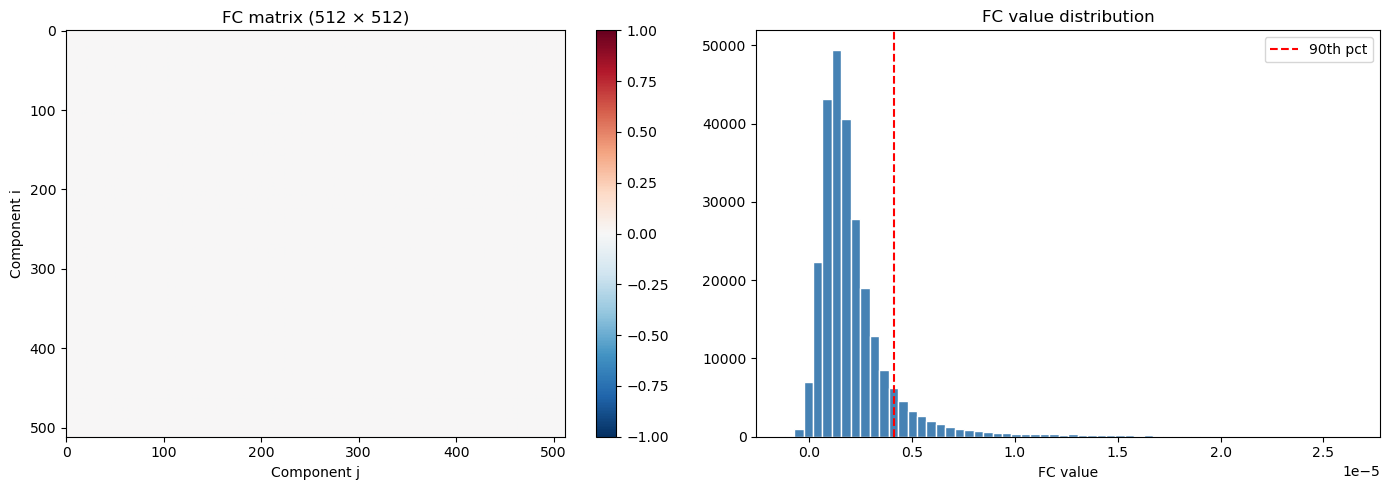

In [6]:
from neurovlm.gnn.graph import load_fc_matrix, compute_fc_from_coefficients

# ── Option A: load from file ──────────────────────────────────────────────────
FC_PATH = None   # e.g. "/data/hcp_difumo512_fc.npy"

# ── Option B: compute from training data (default) ───────────────────────────
if FC_PATH is not None:
    print(f"Loading FC matrix from {FC_PATH}")
    fc = load_fc_matrix(FC_PATH)
else:
    print("Computing FC matrix from DiFuMo co-activation patterns …")
    fc = compute_fc_from_coefficients(difumo_coeffs)

print(f"FC matrix shape : {fc.shape}")
print(f"FC range        : [{fc.min():.4f}, {fc.max():.4f}]")

# Visualise the FC matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im = axes[0].imshow(fc, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
axes[0].set_title(f"FC matrix ({fc.shape[0]} × {fc.shape[1]})")
axes[0].set_xlabel("Component j")
axes[0].set_ylabel("Component i")
plt.colorbar(im, ax=axes[0])

axes[1].hist(fc.ravel(), bins=60, color="steelblue", edgecolor="white")
axes[1].axvline(np.percentile(fc.ravel(), 90), color="red", linestyle="--", label="90th pct")
axes[1].set_title("FC value distribution")
axes[1].set_xlabel("FC value")
axes[1].legend()

plt.tight_layout()
plt.show()

### 1e. Threshold and build the PyG graph

Keep only the top 10% of positive connections. Target average degree: **5 – 80 per node**.  
Adjust `THRESHOLD_PERCENTILE` if the sanity check warns you.

─── Graph sanity check ───
  Nodes        : 512
  Edges        : 13108
  Avg degree   : 25.6
  Edge weight  : min=0.000  max=0.000
  Degree OK.
  Graph is connected.


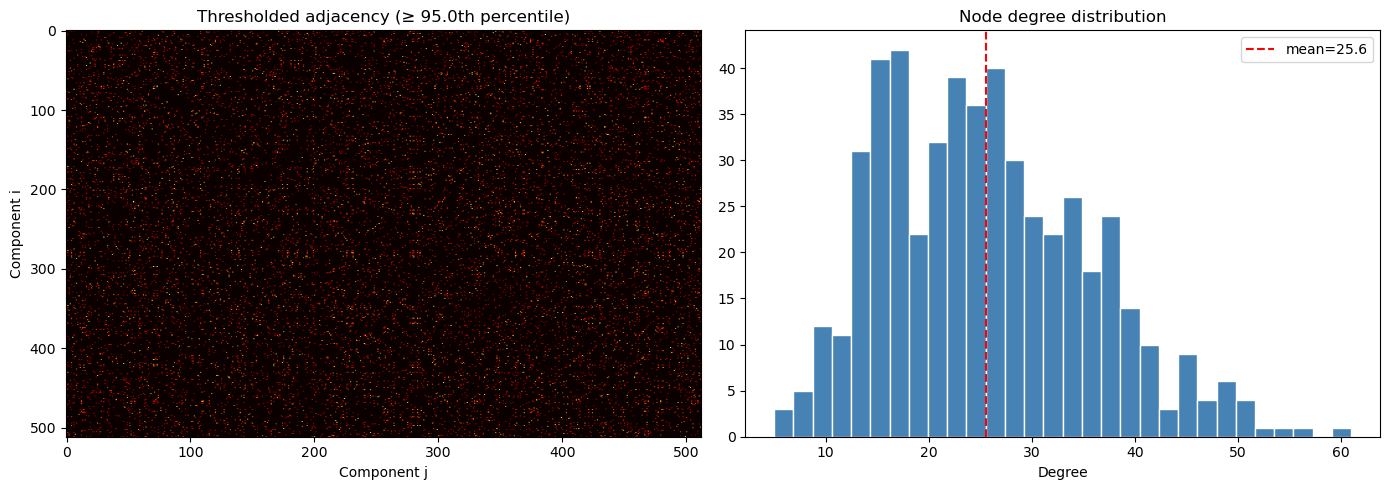


edge_index shape : torch.Size([2, 13108])
edge_attr shape  : torch.Size([13108, 1])


In [7]:
from neurovlm.gnn.graph import threshold_fc_matrix, adjacency_to_pyg, sanity_check_graph

THRESHOLD_PERCENTILE = 95.0   # keep top 5% — good balance of signal vs speed

adj = threshold_fc_matrix(fc, percentile=THRESHOLD_PERCENTILE, positive_only=True)
edge_index, edge_attr = adjacency_to_pyg(adj)

print("─── Graph sanity check ───")
sanity_check_graph(edge_index, edge_attr, n_nodes=DIFUMO_DIM)

# Visualise sparsified adjacency
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].imshow(adj, cmap="hot", aspect="auto")
axes[0].set_title(f"Thresholded adjacency (≥ {THRESHOLD_PERCENTILE}th percentile)")
axes[0].set_xlabel("Component j")
axes[0].set_ylabel("Component i")

degree = np.array([(adj[i] > 0).sum() for i in range(adj.shape[0])])
axes[1].hist(degree, bins=30, color="steelblue", edgecolor="white")
axes[1].axvline(degree.mean(), color="red", linestyle="--", label=f"mean={degree.mean():.1f}")
axes[1].set_title("Node degree distribution")
axes[1].set_xlabel("Degree")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nedge_index shape : {edge_index.shape}")
print(f"edge_attr shape  : {edge_attr.shape}")

---
## Phase 2 — Build the PyG Dataset

Align brain coefficients with precomputed SPECTER text embeddings via PMID, then wrap everything in a `BrainGraphDataset` and split into train / val / test.

In [8]:
from neurovlm.data import load_latent

text_latents = load_latent("pubmed_text")   # (N_text, 768) SPECTER embeddings
pubmed_df    = load_dataset("pubmed_text")  # DataFrame: pmid, doi, title, abstract

print(f"Text latents type  : {type(text_latents)}")
if isinstance(text_latents, torch.Tensor):
    print(f"Text latents shape : {text_latents.shape}")
elif isinstance(text_latents, dict):
    print(f"Text latents keys  : {len(text_latents)} (dict keyed by pmid)")
print(f"PubMed df columns  : {list(pubmed_df.columns)}")
print(f"PubMed df shape    : {pubmed_df.shape}")

Text latents type  : <class 'tuple'>
PubMed df columns  : ['pmid', 'pmcid', 'doi', 'name', 'description', 'train', 'test', 'val']
PubMed df shape    : (30826, 8)


In [9]:
# load_latent("pubmed_text") returns (embeddings_tensor, pmids_array)
text_tensor, text_pmids = text_latents   # (N_text, 768) and (N_text,)
text_pmids = np.asarray(text_pmids).astype(str)

print(f"text_tensor : {text_tensor.shape}  (N_text × 768)")
print(f"text_pmids  : {text_pmids.shape}   sample={text_pmids[:3]}")

# Build pmid → row-index lookup for the text tensor
pmid_to_text_idx = {pmid: i for i, pmid in enumerate(text_pmids)}

# Brain flatmaps also come with PMIDs — join them
brain_rows, text_rows = [], []
for i, pmid in enumerate(pmids):
    key = str(pmid)
    if key in pmid_to_text_idx:
        brain_rows.append(i)
        text_rows.append(pmid_to_text_idx[key])

if brain_rows:
    aligned_brain = difumo_coeffs[brain_rows]
    aligned_text  = text_tensor[text_rows].numpy()
    print(f"\nAligned {len(brain_rows):,} paired (brain, text) samples via PMID.")
else:
    # Fallback: row-aligned (should not normally happen)
    n = min(len(difumo_coeffs), len(text_tensor))
    aligned_brain = difumo_coeffs[:n]
    aligned_text  = text_tensor[:n].numpy()
    print(f"\nNo PMID matches found — assuming row-aligned. Using {n:,} samples.")

print(f"aligned_brain : {aligned_brain.shape}")
print(f"aligned_text  : {aligned_text.shape}")

text_tensor : torch.Size([30826, 768])  (N_text × 768)
text_pmids  : (30826,)   sample=['1589767' '8530552' '8624678']

Aligned 30,784 paired (brain, text) samples via PMID.
aligned_brain : (30784, 512)
aligned_text  : (30784, 768)


In [10]:
from neurovlm.gnn.atlas import get_component_centroids

# MNI bounding-box half-widths (mm) for each axis
MNI_SCALE = torch.tensor([90.0, 126.0, 108.0])   # x, y, z

centroids_mni = get_component_centroids(dimension=DIFUMO_DIM)  # (512, 3) in mm
centroids_norm = torch.tensor(centroids_mni, dtype=torch.float32) / MNI_SCALE  # → [-1, 1]

print(f"Centroids shape : {centroids_norm.shape}")
print(f"Range x : [{centroids_norm[:,0].min():.2f}, {centroids_norm[:,0].max():.2f}]")
print(f"Range y : [{centroids_norm[:,1].min():.2f}, {centroids_norm[:,1].max():.2f}]")
print(f"Range z : [{centroids_norm[:,2].min():.2f}, {centroids_norm[:,2].max():.2f}]")


[fetch_atlas_difumo] Dataset found in /Users/borng/nilearn_data/difumo_atlases

Centroids shape : torch.Size([512, 3])
Range x : [-0.71, 0.71]
Range y : [-0.79, 0.54]
Range z : [-0.51, 0.74]


In [11]:
from neurovlm.gnn.dataset import BrainGraphDataset

SEED = 42

full_ds = BrainGraphDataset(
    difumo_coeffs    = torch.tensor(aligned_brain, dtype=torch.float32),
    edge_index       = edge_index,
    edge_attr        = edge_attr,
    text_embeddings  = torch.tensor(aligned_text,  dtype=torch.float32),
    extra_node_feats = centroids_norm,   # (512, 3) MNI x,y,z → in_dim becomes 4
)

train_ds, val_ds, test_ds = full_ds.split(val_frac=0.1, test_frac=0.1, seed=SEED)

# Confirm node feature dim = 4
sample = full_ds[0]
assert sample.x.shape == (DIFUMO_DIM, 4), f"Expected (512, 4), got {sample.x.shape}"
print(f"Full dataset : {len(full_ds):,}")
print(f"Train        : {len(train_ds):,}")
print(f"Val          : {len(val_ds):,}")
print(f"Test         : {len(test_ds):,}")
print(f"Node feature dim : {sample.x.shape[1]}  ✓ (activation + x + y + z)")


Full dataset : 30,784
Train        : 24,628
Val          : 3,078
Test         : 3,078
Node feature dim : 4  ✓ (activation + x + y + z)


In [12]:
# Inspect one sample
sample = full_ds[0]
print("One Data object:")
print(f"  x          : {sample.x.shape}   (512 nodes × 1 feature)")
print(f"  edge_index : {sample.edge_index.shape}   (2 × E)")
print(f"  edge_attr  : {sample.edge_attr.shape}  (E × 1)")
print(f"  y          : {sample.y.shape}      (SPECTER embedding)")
print(f"\n  x range    : [{sample.x.min():.3f}, {sample.x.max():.3f}]")
print(f"  y range    : [{sample.y.min():.3f}, {sample.y.max():.3f}]")

One Data object:
  x          : torch.Size([512, 4])   (512 nodes × 1 feature)
  edge_index : torch.Size([2, 13108])   (2 × E)
  edge_attr  : torch.Size([13108, 1])  (E × 1)
  y          : torch.Size([1, 768])      (SPECTER embedding)

  x range    : [-0.789, 6.103]
  y range    : [-0.094, 0.372]


---
## Phase 3 — Build the GAT Model

Three-layer Graph Attention Network:

```
(512 nodes, in_dim=1) → GATConv(64, heads=8) → GATConv(64, heads=8) → GATConv(64, heads=1) → global_mean_pool → Linear → (384,)
```

`TextProjHead` maps frozen SPECTER 768-dim embeddings → 384-dim for InfoNCE alignment.

In [13]:
from neurovlm.gnn.model import BrainGAT, TextProjHead

# ── Hyperparameters ───────────────────────────────────────────────────────────
GAT_HIDDEN  = 32    # tuned for MPS 16 GB
GAT_HEADS   = 4
GAT_OUT_DIM = 384
GAT_DROPOUT = 0.1

brain_encoder = BrainGAT(
    in_dim  = 4,    # activation (1) + MNI x, y, z (3)
    hidden  = GAT_HIDDEN,
    heads   = GAT_HEADS,
    out_dim = GAT_OUT_DIM,
    dropout = GAT_DROPOUT,
)

text_proj = TextProjHead(in_dim=768, hidden_dim=512, out_dim=GAT_OUT_DIM)

n_brain = sum(p.numel() for p in brain_encoder.parameters())
n_text  = sum(p.numel() for p in text_proj.parameters())
print(f"BrainGAT params      : {n_brain:,}")
print(f"TextProjHead params  : {n_text:,}")
print(f"Total trainable      : {n_brain + n_text:,}")
print()
print(brain_encoder)


BrainGAT params      : 34,528
TextProjHead params  : 590,720
Total trainable      : 625,248

BrainGAT(
  (conv1): GATConv(4, 32, heads=4)
  (conv2): GATConv(128, 32, heads=4)
  (conv3): GATConv(128, 32, heads=1)
  (proj): Linear(in_features=32, out_features=384, bias=True)
)


In [14]:
# End-to-end shape verification with a single fake batch
from torch_geometric.data import Data, Batch

dummy_graphs = [
    Data(
        x          = torch.randn(DIFUMO_DIM, 4),  # activation + x,y,z
        edge_index = edge_index,
        edge_attr  = edge_attr,
        y          = torch.randn(1, 768),
    )
    for _ in range(4)
]
batch = Batch.from_data_list(dummy_graphs)

print(f"batch.x shape : {batch.x.shape}   expected ({DIFUMO_DIM*4}, 4)")
print(f"batch.y shape : {batch.y.shape}   expected (4, 768)")

with torch.no_grad():
    brain_out = brain_encoder(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
    text_out  = text_proj(batch.y)

print(f"brain_encoder output : {brain_out.shape}   ✓ (4, 384)")
print(f"text_proj output     : {text_out.shape}    ✓ (4, 384)")
assert brain_out.shape == (4, 384)
assert text_out.shape  == (4, 384)
print("\nShape check passed.")


batch.x shape : torch.Size([2048, 4])   expected (2048, 4)
batch.y shape : torch.Size([4, 768])   expected (4, 768)
brain_encoder output : torch.Size([4, 384])   ✓ (4, 384)
text_proj output     : torch.Size([4, 384])    ✓ (4, 384)

Shape check passed.


---
## Phase 4 — Training

**Objective:** InfoNCE contrastive loss between GAT brain embeddings and projected SPECTER text embeddings.

**Schedule:** linear LR warmup for 10 epochs → cosine decay.

**Monitoring:** validation recall@k AUC every `val_interval` epochs.  
If the model hasn't approached AUC 0.75 by epoch 50, check that DiFuMo coefficients were z-scored.

In [15]:
from neurovlm.gnn.train import GATTrainer

# ── Training hyperparameters ──────────────────────────────────────────────────
# With 98th-percentile threshold (~2600 edges/graph) batch_size=64 uses ~0.5 GB.
# Epoch time on MPS should be ~30–60 s.
N_EPOCHS       = 150
BATCH_SIZE     = 64
LR_GAT         = 1e-4
LR_PROJ        = 1e-5
WARMUP_EPOCHS  = 10
TEMPERATURE    = 0.07
VAL_INTERVAL   = 5
CHECKPOINT_DIR = repo_root / "checkpoints" / "gat"

trainer = GATTrainer(
    brain_encoder  = brain_encoder,
    text_proj      = text_proj,
    lr_gat         = LR_GAT,
    lr_proj        = LR_PROJ,
    batch_size     = BATCH_SIZE,
    n_epochs       = N_EPOCHS,
    warmup_epochs  = WARMUP_EPOCHS,
    temperature    = TEMPERATURE,
    device         = "auto",
    val_interval   = VAL_INTERVAL,
    checkpoint_dir = str(CHECKPOINT_DIR),
    verbose        = True,
)

trainer.fit(train_ds, val_ds)


Training BrainGAT: 150 epochs, batch=64, device=mps
  train=24628  val=3078
Epoch    0/150 | loss=4.1695 | recall_t2i=0.5072 | recall_i2t=0.5023 | lr=1.00e-05
  → checkpoint saved to /Users/borng/code/lab_work/neurovlm/checkpoints/gat/best_gat.pt
Epoch    5/150 | loss=4.0649 | recall_t2i=0.6104 | recall_i2t=0.6072 | lr=6.00e-05
  → checkpoint saved to /Users/borng/code/lab_work/neurovlm/checkpoints/gat/best_gat.pt
Epoch    7/150 | loss=4.0400 | lr=8.00e-05
Epoch   10/150 | loss=4.0052 | recall_t2i=0.6406 | recall_i2t=0.6337 | lr=1.00e-04
  → checkpoint saved to /Users/borng/code/lab_work/neurovlm/checkpoints/gat/best_gat.pt
Epoch   14/150 | loss=3.8562 | lr=9.97e-05
Epoch   15/150 | loss=3.8160 | recall_t2i=0.6997 | recall_i2t=0.6973 | lr=9.95e-05
  → checkpoint saved to /Users/borng/code/lab_work/neurovlm/checkpoints/gat/best_gat.pt
Epoch   20/150 | loss=3.6396 | recall_t2i=0.7348 | recall_i2t=0.7319 | lr=9.85e-05
  → checkpoint saved to /Users/borng/code/lab_work/neurovlm/checkpoints

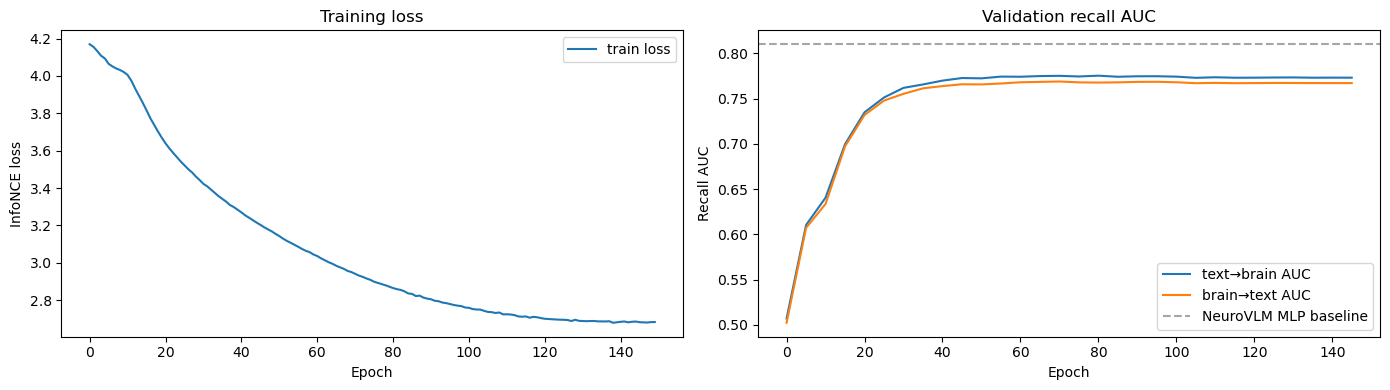

In [22]:
# Plot training curves
history = trainer.history
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history["train_loss"], label="train loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("InfoNCE loss")
axes[0].set_title("Training loss")
axes[0].legend()

val_epochs = list(range(0, N_EPOCHS, VAL_INTERVAL))[:len(history["val_recall_t2i"])]
axes[1].plot(val_epochs, history["val_recall_t2i"], label="text→brain AUC")
axes[1].plot(val_epochs, history["val_recall_i2t"], label="brain→text AUC")
axes[1].axhline(0.81, color="gray", linestyle="--", alpha=0.7, label="NeuroVLM MLP baseline")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Recall AUC")
axes[1].set_title("Validation recall AUC")
axes[1].legend()

plt.tight_layout()
plt.show()

---
## Phase 5 — Evaluation

### 5a. Recall@k on val and test sets

Report recall@1, @5, @10 and the AUC of the full recall curve for both
text→brain and brain→text retrieval.  Compare to the NeuroVLM MLP baseline.

In [23]:
from neurovlm.metrics import recall_at_k, recall_curve
from torch_geometric.loader import DataLoader as PyGDataLoader

trainer.restore_best()
brain_encoder_eval = trainer.brain_encoder.eval()
text_proj_eval     = trainer.text_proj.eval()
device             = trainer.device

@torch.no_grad()
def collect_embeddings(ds):
    loader = PyGDataLoader(ds, batch_size=256, shuffle=False)
    all_b, all_t = [], []
    for batch in loader:
        batch = batch.to(device)
        b = brain_encoder_eval(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
        t = text_proj_eval(batch.y)
        all_b.append(b.cpu())
        all_t.append(t.cpu())
    return torch.cat(all_b), torch.cat(all_t)

results = {}
for split_name, ds in [("Val", val_ds), ("Test", test_ds)]:
    brain_emb, text_emb = collect_embeddings(ds)
    bn = F.normalize(brain_emb, dim=1)
    tn = F.normalize(text_emb,  dim=1)
    sim = tn @ bn.T

    r1  = recall_at_k(sim, 1)
    r5  = recall_at_k(sim, 5)
    r10 = recall_at_k(sim, 10)
    t2i, i2t = recall_curve(text_emb, brain_emb)
    auc = float((t2i.mean() + i2t.mean()) / 2)

    results[split_name] = dict(r1=r1, r5=r5, r10=r10, auc=auc,
                               t2i=t2i.cpu(), i2t=i2t.cpu(), n=len(ds))
    print(f"\n{split_name} ({len(ds):,} papers)")
    print(f"  recall@1  = {r1:.4f}")
    print(f"  recall@5  = {r5:.4f}")
    print(f"  recall@10 = {r10:.4f}")
    print(f"  AUC       = {auc:.4f}   (NeuroVLM MLP ≈ 0.81)")


Val (3,078 papers)
  recall@1  = 0.0065
  recall@5  = 0.0312
  recall@10 = 0.0604
  AUC       = 0.7720   (NeuroVLM MLP ≈ 0.81)

Test (3,078 papers)
  recall@1  = 0.0084
  recall@5  = 0.0244
  recall@10 = 0.0497
  AUC       = 0.7717   (NeuroVLM MLP ≈ 0.81)


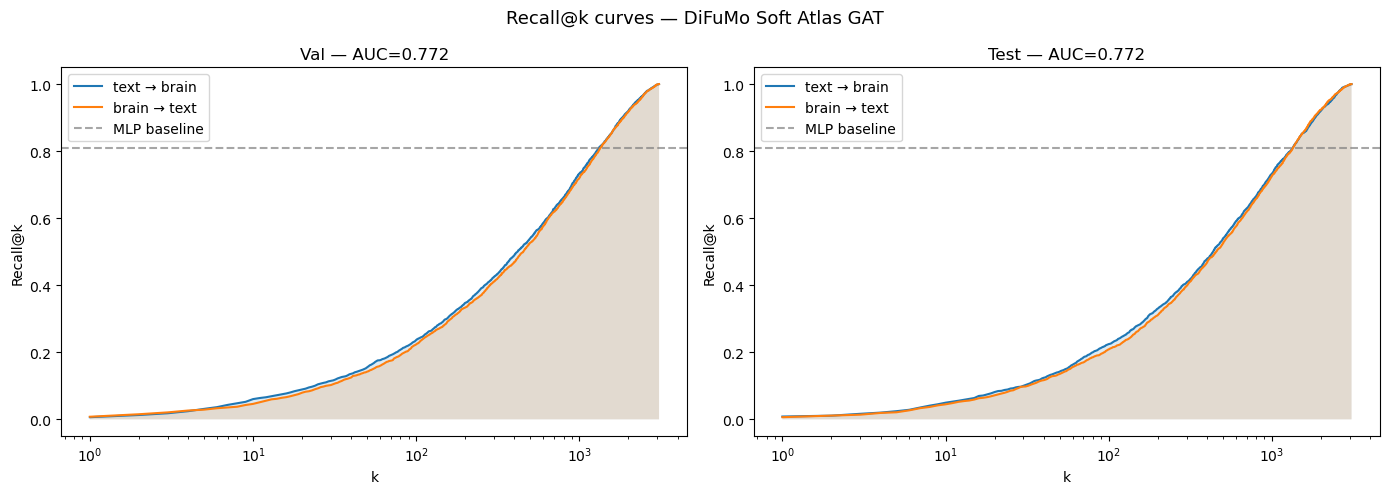

In [24]:
# Plot recall curves for val and test
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, split_name in zip(axes, ["Val", "Test"]):
    r = results[split_name]
    n = r["n"]
    ks = np.arange(1, n + 1)
    ax.plot(ks, r["t2i"].numpy(), label="text → brain")
    ax.plot(ks, r["i2t"].numpy(), label="brain → text")
    ax.axhline(0.81, color="gray", linestyle="--", alpha=0.7, label="MLP baseline")
    ax.fill_between(ks, r["t2i"].numpy(), alpha=0.15)
    ax.fill_between(ks, r["i2t"].numpy(), alpha=0.15)
    ax.set_xlabel("k")
    ax.set_ylabel("Recall@k")
    ax.set_title(f"{split_name} — AUC={r['auc']:.3f}")
    ax.set_xscale("log")
    ax.legend()

plt.suptitle("Recall@k curves — DiFuMo Soft Atlas GAT", fontsize=13)
plt.tight_layout()
plt.show()

### 5b. Attention weight inspection

Which edges does the GAT pay most attention to?  
For interpretability: high-attention edges in known networks (DMN, motor) should connect neurologically plausible component pairs.

In [25]:
snap = trainer.get_attention_snapshot(val_ds, n_samples=128)

ei   = snap["edge_index"]           # (2, E_batch)
attn = snap["attn_mean"]            # (E_batch,) — averaged over heads + samples

# Top-20 highest-attention edges
k = 20
top = attn.topk(k)
print(f"Top {k} attention edges (layer 3, mean over {min(128, len(val_ds))} samples):")
print(f"  {'rank':>4}  {'src':>6} → {'dst':>6}   attn")
for rank, (idx, val) in enumerate(zip(top.indices.tolist(), top.values.tolist())):
    s = ei[0, idx].item()
    d = ei[1, idx].item()
    print(f"  {rank+1:4d}  {s:6d} → {d:6d}   {val:.4f}")

Top 20 attention edges (layer 3, mean over 128 samples):
  rank     src →    dst   attn
     1   34055 →  34156   0.8700
     2   11015 →  11116   0.8400
     3   34120 →  34236   0.8222
     4   14087 →  14255   0.8095
     5   33951 →  34157   0.8088
     6   34055 →  34223   0.8085
     7   38663 →  38764   0.7998
     8   63239 →  63340   0.7982
     9   14087 →  14188   0.7939
    10   32007 →  32108   0.7924
    11   27399 →  27500   0.7647
    12   21767 →  21868   0.7615
    13   64775 →  64876   0.7542
    14   61703 →  61804   0.7493
    15   51975 →  52076   0.7476
    16   35591 →  35692   0.7433
    17    8455 →   8556   0.7418
    18   58631 →  58732   0.7398
    19   52999 →  53100   0.7374
    20   28935 →  29036   0.7330


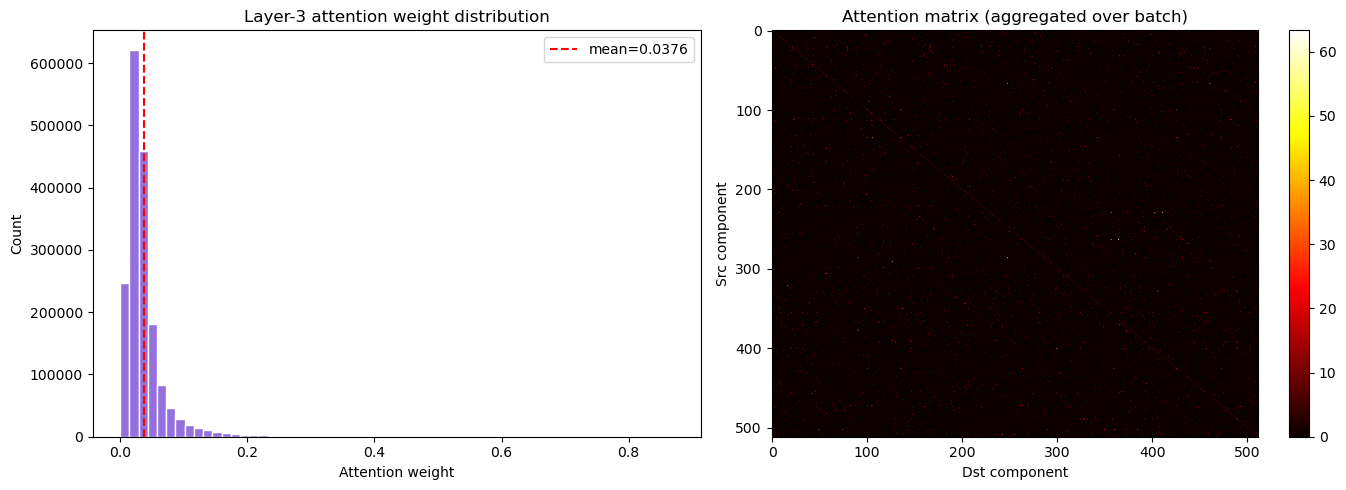

In [26]:
# Visualise the attention distribution and the sparse attention adjacency matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of all attention weights
axes[0].hist(attn.numpy(), bins=60, color="mediumpurple", edgecolor="white")
axes[0].axvline(attn.mean().item(), color="red", linestyle="--",
                label=f"mean={attn.mean().item():.4f}")
axes[0].set_title("Layer-3 attention weight distribution")
axes[0].set_xlabel("Attention weight")
axes[0].set_ylabel("Count")
axes[0].legend()

# Sparse attention matrix — use only unique src/dst to avoid batch repetition
n_nodes = DIFUMO_DIM
attn_mat = np.zeros((n_nodes, n_nodes), dtype=np.float32)
src_all = ei[0].numpy() % n_nodes
dst_all = ei[1].numpy() % n_nodes
np.add.at(attn_mat, (src_all, dst_all), attn.numpy())

im = axes[1].imshow(attn_mat, cmap="hot", aspect="auto")
axes[1].set_title("Attention matrix (aggregated over batch)")
axes[1].set_xlabel("Dst component")
axes[1].set_ylabel("Src component")
plt.colorbar(im, ax=axes[1])

plt.tight_layout()
plt.show()

### 5c. Per-component attention — which brain regions matter most?

Average the incoming attention weight per node (component). High values indicate components the GAT relies on most when reading the graph.

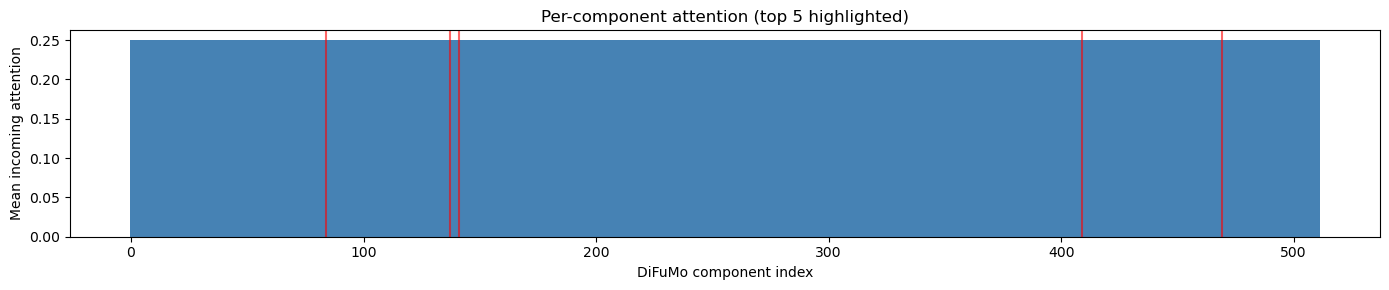

Top 5 most-attended components: [137, 469, 84, 409, 141]
(Look up these component indices in the DiFuMo atlas labels to identify brain regions)


In [27]:
# Per-node (component) mean incoming attention
node_attn = attn_mat.mean(axis=0)   # mean over src → shape (512,)

fig, ax = plt.subplots(figsize=(14, 3))
ax.bar(range(DIFUMO_DIM), node_attn, width=1.0, color="steelblue")
top5_nodes = np.argsort(node_attn)[-5:][::-1]
for node in top5_nodes:
    ax.axvline(node, color="red", alpha=0.6, linewidth=1.5)
ax.set_xlabel("DiFuMo component index")
ax.set_ylabel("Mean incoming attention")
ax.set_title("Per-component attention (top 5 highlighted)")
plt.tight_layout()
plt.show()

print(f"Top 5 most-attended components: {top5_nodes.tolist()}")
print("(Look up these component indices in the DiFuMo atlas labels to identify brain regions)")

In [28]:
# Look up DiFuMo component labels for the top-attended nodes
try:
    from nilearn import datasets as nilearn_datasets
    atlas = nilearn_datasets.fetch_atlas_difumo(dimension=DIFUMO_DIM, resolution_mm=2)
    labels = atlas.labels if hasattr(atlas, "labels") else None

    if labels is not None:
        print("Top attended components with labels:")
        for node in top5_nodes:
            label = labels[node] if node < len(labels) else "?"
            print(f"  Component {node:4d}  attention={node_attn[node]:.4f}  →  {label}")
    else:
        print("No labels found in atlas object; print atlas keys:")
        print(dir(atlas))
except Exception as e:
    print(f"Could not load labels: {e}")
    print(f"Top attended components (by index): {top5_nodes.tolist()}")

[fetch_atlas_difumo] Dataset found in /Users/borng/nilearn_data/difumo_atlases

Top attended components with labels:
Could not load labels: np.int64(137)
Top attended components (by index): [137, 469, 84, 409, 141]


---
## Summary & next steps

| Metric | NeuroVLM MLP baseline | DiFuMo GAT (this run) |
|---|---|---|
| Recall@1 | — | see above |
| Recall@5 | — | see above |
| Recall@10 | — | see above |
| Val AUC | ≈ 0.81 | see above |

**If AUC < 0.75 at epoch 50:**
- Confirm `difumo_coeffs` is z-scored (`normalize=True` in cell 1c).
- Try lowering `THRESHOLD_PERCENTILE` to 80 (denser graph → more signal).
- Try increasing `GAT_HIDDEN` to 128.

**If AUC > 0.81 — next steps:**
- Add centroid coordinates as node features: set `ADD_CENTROIDS = True` and re-run.
- Replace the co-activation FC proxy with a real HCP resting-state FC matrix.
- Try 5-fold CV with the same DOI-based holdout as the NeuroVLM paper.
- Swap `GATConv` for `GATv2Conv` (recomputes attention per layer) for stronger expressivity.